<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jiju jayakumar\AppData\Local\Temp\ipykernel_32800\2592309994.py:10: SyntaxWarning: invalid escape sequence '\d'
  ski.io.imshow("D:/F1_CCTB\data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif")
C:\Users\jiju jayakumar\AppData\Local\Temp\ipykernel_32800\2592309994.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  ski.io.imshow("D:/F1_CCTB\data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif")
c:\Users\jiju jayakumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\io\_io.py:232: FutureWarning: `call_plugin` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages d

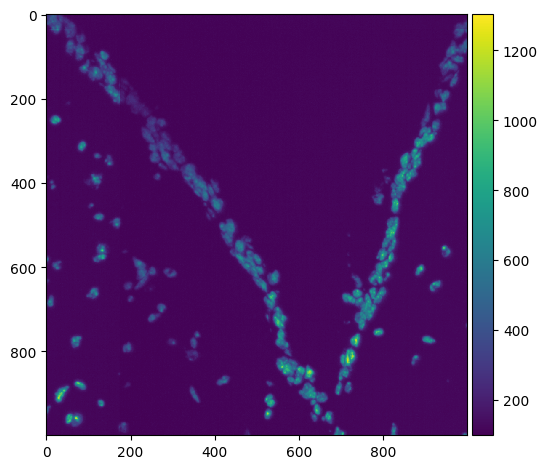

In [1]:
import matplotlib.pyplot as plt
import glob # for working with multiple files
import skimage as ski
import skimage.io as io
import os



# plot one image
ski.io.imshow("D:/F1_CCTB\data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif")





<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
C:\Users\jiju jayakumar\AppData\Local\Temp\ipykernel_32800\1322709411.py:3: SyntaxWarning: invalid escape sequence '\F'
  x10y10 = glob.glob("D:\F1_CCTB\data\S-BSST700\selected-tiles\selected-tiles\out_opt_flow_registered_X10_Y10_*.tif")
C:\Users\jiju jayakumar\AppData\Local\Temp\ipykernel_32800\1322709411.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  ski.io.imshow(images_x10y10[5])
c:\Users\jiju jayakumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


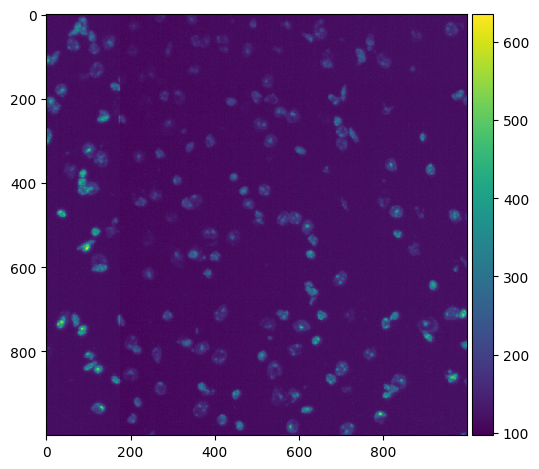

In [2]:
#Create a figure that incorporates all runs (c1 - c4) of one tile as subplots.
#create a list of file for all images of tile X10_Y10
x10y10 = glob.glob("D:\F1_CCTB\data\S-BSST700\selected-tiles\selected-tiles\out_opt_flow_registered_X10_Y10_*.tif")


#sort again to have a right c01 -> c04 order
x10y10 = sorted(x10y10)

#read all imgaes into a list
images_x10y10 = [ski.io.imread(img) for img in x10y10]

# Display the first image as a check at dapi channel
ski.io.imshow(images_x10y10[5])

In [3]:
fig, axs = plt.subplots(4, 6, figsize=(25, 15))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(images_x10y10[i])
    #filename = os.path.basename(x10y10[i])
    #ax.set_title(filename, fontsize=8)
plt.show()






KeyboardInterrupt: 

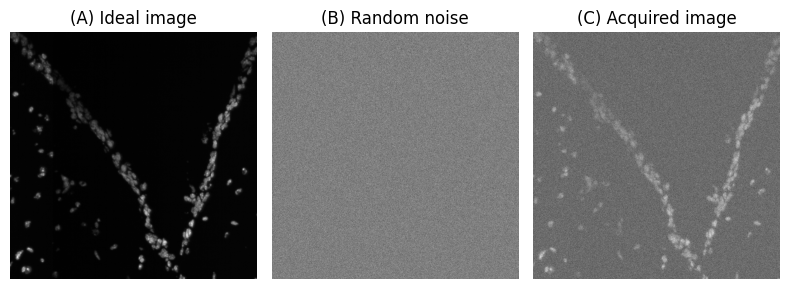

In [ ]:

import numpy as np

# Load a sample image, normalize between 0 and 5
im = io.imread(r"D:/F1_CCTB/data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif")
im = im - im.min()
im = im / im.max() * 5
# Create a random number generator 
# to keep the randomness predictable each time we run the code...
rng = np.random.default_rng(100)

# Create a normally-distributed random value for every pixel
# Mean = 0, Std. dev. 1

im_noise = rng.normal(size=im.shape)
im_possible = im + im_noise

fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 3, 1); ax1.imshow(im, cmap="gray"); ax1.set_title("(A) Ideal image"); ax1.axis("off")
ax2 = fig.add_subplot(1, 3, 2); ax2.imshow(im_noise, cmap="gray"); ax2.set_title("(B) Random noise"); ax2.axis("off")
ax3 = fig.add_subplot(1, 3, 3); ax3.imshow(im_possible, cmap="gray"); ax3.set_title("(C) Acquired image"); ax3.axis("off")
plt.tight_layout()
plt.show()


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jiju jayakumar\AppData\Local\Temp\ipykernel_10424\1400371350.py:7: SyntaxWarning: invalid escape sequence '\d'
  path = "D:/F1_CCTB\data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c02_DAPI.tif"


Number of nuclei: 310


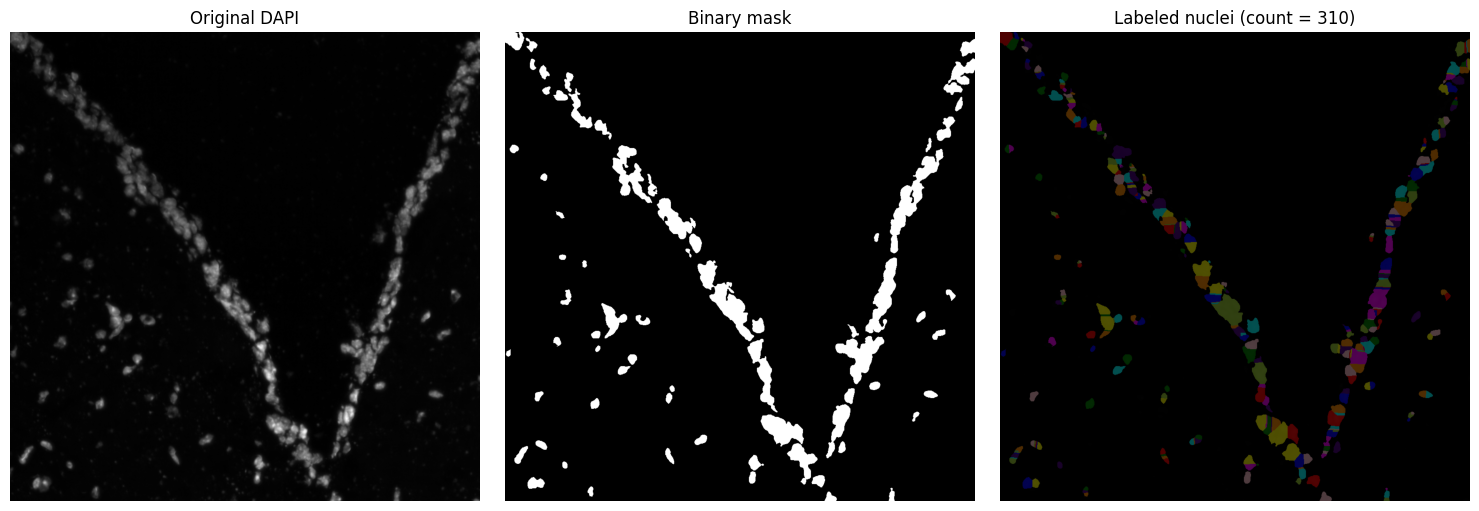

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, measure, segmentation, color
from scipy import ndimage as ndi

# 1. Load one FOV (use DAPI / nuclear channel)
path = "D:/F1_CCTB\data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c02_DAPI.tif"
img = io.imread(path)  

# 2. Preprocessing: smooth to reduce noise
smoothed = filters.gaussian(img, sigma=1.0)

# 3. Thresholding: separate nuclei from background
thr = filters.threshold_otsu(smoothed)
binary = smoothed > thr

# 4. Morphological cleanup
binary = morphology.remove_small_objects(binary, min_size =100)
binary = morphology.remove_small_holes(binary, area_threshold=100)

# 5. Distance transform + watershed for instance separation
distance = ndi.distance_transform_edt(binary)
# peaks as markers
local_max = morphology.local_maxima(distance)
markers, _ = ndi.label(local_max)
labels = segmentation.watershed(-distance, markers, mask=binary)

# 6. Count nuclei

n_nuclei = labels.max()
print("Number of nuclei:", n_nuclei)

# 7.  figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original DAPI")
axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

overlay = color.label2rgb(labels, image=img, bg_label=0, alpha=0.3)
axes[2].imshow(overlay)
axes[2].set_title(f"Labeled nuclei (count = {n_nuclei})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


Number of nuclei: 90


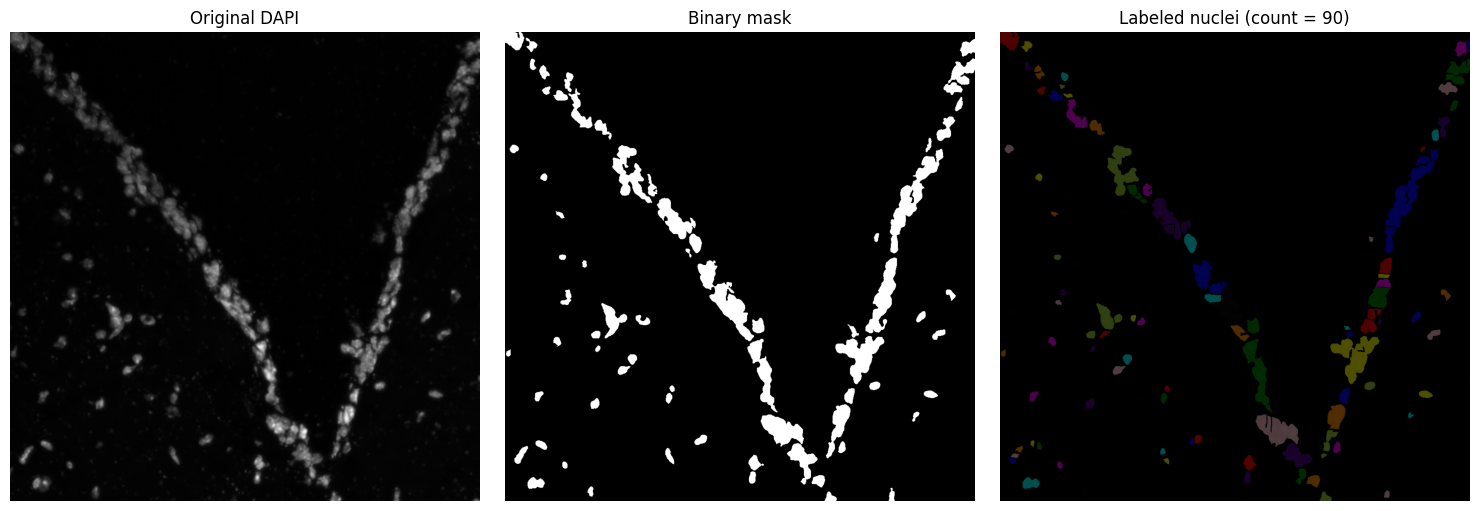

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, measure, segmentation, color
from scipy import ndimage as ndi

# 1. Load one FOV (use DAPI / nuclear channel)
path = r"D:/F1_CCTB/data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c02_DAPI.tif"
img = io.imread(path)

# 2. Preprocessing: smooth to reduce noise
smoothed = filters.gaussian(img, sigma=1.0)

# 3. Thresholding: separate nuclei from background
thr = filters.threshold_otsu(smoothed)
binary = smoothed > thr

# 4. Morphological cleanup
binary = morphology.remove_small_objects(binary, min_size=100)
binary = morphology.remove_small_holes(binary, area_threshold=100)

# 5. Distance transform + watershed for instance separation
distance = ndi.distance_transform_edt(binary)
local_max = morphology.local_maxima(distance)
markers, _ = ndi.label(local_max)
labels = segmentation.watershed(-distance, markers, mask=binary)

# 5b. Filter by area (remove very small + very big objects)
min_area = 80      # too small  -> fragments
max_area = 1500    # too large -> debris

props = measure.regionprops(labels)
mask_keep = np.zeros_like(labels, dtype=bool) 

for p in props:
    if min_area <= p.area <= max_area: #Checks whether this object’s size lies in the allowed range (nucleus-sized).
        mask_keep[labels == p.label] = True
# mask_keep is True only for pixels that belong to objects within the chosen area range; all other objects (too small or too big) remain False and will be removed when you relabel.
labels = measure.label(mask_keep)

# 6. Count nuclei
n_nuclei = labels.max()
print("Number of nuclei:", n_nuclei)

# 7. figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original DAPI")
axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

overlay = color.label2rgb(labels, image=img, bg_label=0, alpha=0.3)
axes[2].imshow(overlay)
axes[2].set_title(f"Labeled nuclei (count = {n_nuclei})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


Number of nuclei: 166


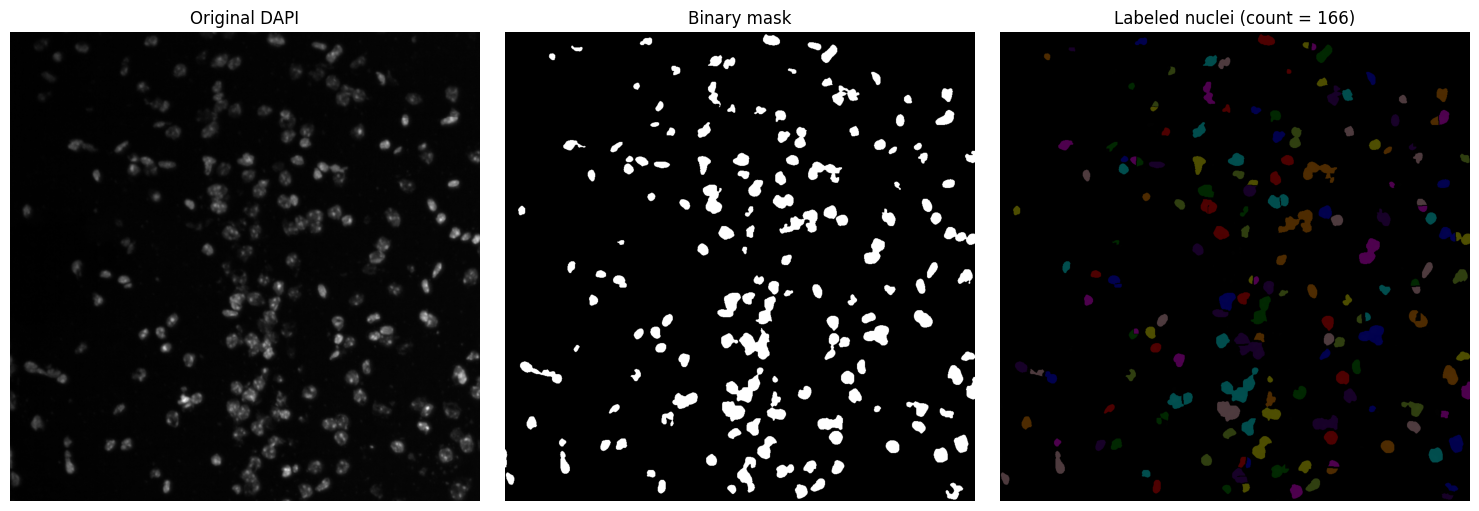

In [ ]:


# 1. Load one FOV (use DAPI / nuclear channel)
path = r"D:/F1_CCTB/data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X11_Y4_c03_DAPI.tif"
img = io.imread(path)

# 2. Preprocessing: smooth to reduce noise
smoothed = filters.gaussian(img, sigma=1.5)

# 3. Thresholding: separate nuclei from background
thr = filters.threshold_otsu(smoothed)
binary = smoothed > thr

# 4. Morphological cleanup
binary = morphology.remove_small_objects(binary, min_size=100)
binary = morphology.remove_small_holes(binary, area_threshold=100)

# 5. Distance transform + watershed for instance separation
distance = ndi.distance_transform_edt(binary)
local_max = morphology.local_maxima(distance)
markers, _ = ndi.label(local_max)
labels = segmentation.watershed(-distance, markers, mask=binary)

# 5b. Filter by area (remove very small + very big objects)
min_area = 80      # too small  -> fragments
max_area = 2000  # too large -> debris

props = measure.regionprops(labels)
mask_keep = np.zeros_like(labels, dtype=bool) 

for p in props:
    if min_area <= p.area <= max_area: #Checks whether this object’s size lies in the allowed range (nucleus-sized).
        mask_keep[labels == p.label] = True
# mask_keep is True only for pixels that belong to objects within the chosen area range; all other objects (too small or too big) remain False and will be removed when you relabel.
labels = measure.label(mask_keep)

# 6. Count nuclei
n_nuclei = labels.max()
print("Number of nuclei:", n_nuclei)

# 7. figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original DAPI")
axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

overlay = color.label2rgb(labels, image=img, bg_label=0, alpha=0.3)
axes[2].imshow(overlay)
axes[2].set_title(f"Labeled nuclei (count = {n_nuclei})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, segmentation, color
from scipy import ndimage as ndi

# 1. load mouse embryo (4D: e.g. z, c, y, x)
path = r"D:\F1_CCTB\CD1-DapiB-Gata6G-TotalR-NanogM-embryo2.lsm"
img_4d = io.imread(path)          # shape ~ (78, 5, 512, 512)
                                  # Dimension breakdown 
                                  # 78 = Z-slices (depth, 78 optical sections through embryo thickness)
                                  # 5 = Channels (5 fluorescent markers: DAPI, Gata6, TotalR, NanogM,...)
                                  # 512 = Y-pixels (image height)
                                  # 512 = X-pixels (image width)
print(img_4d.shape)



(78, 5, 512, 512)


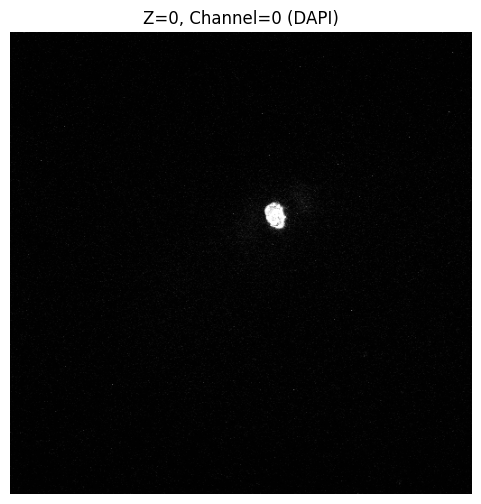

In [ ]:
import matplotlib.pyplot as plt

# Show first Z-slice, first channel ( DAPI)
plt.figure(figsize=(6, 6))
plt.imshow(img_4d[0, 0], cmap='gray')
plt.title('Z=0, Channel=0 (DAPI)')
plt.axis('off')
plt.show()


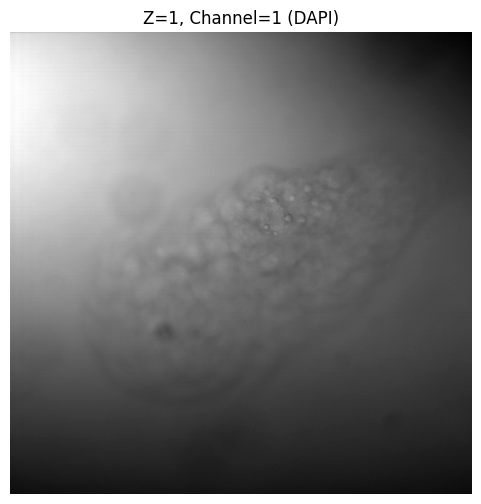

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(img_4d[1, 1], cmap='gray')
plt.title('Z=1, Channel=1 (DAPI)')
plt.axis('off')
plt.show()

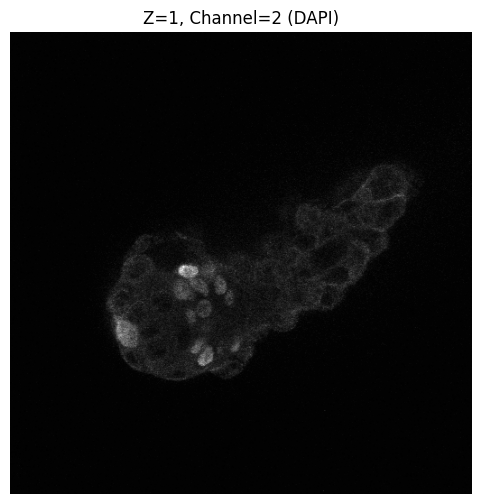

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(img_4d[50, 2], cmap='gray')
plt.title('Z=1, Channel=2 (DAPI)')
plt.axis('off')
plt.show()

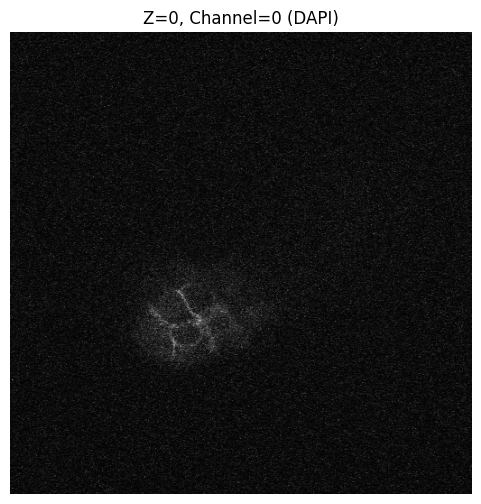

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(img_4d[71, 3], cmap='gray')
plt.title('Z=0, Channel=0 (DAPI)')
plt.axis('off')
plt.show()

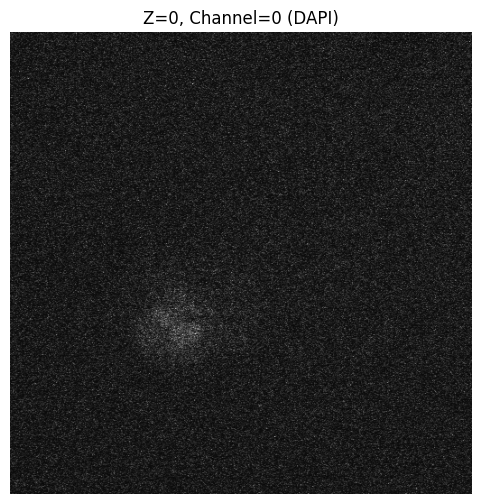

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(img_4d[71, 4], cmap='grey')
plt.title('Z=0, Channel=0 (DAPI)')
plt.axis('off')
plt.show()

Number of nuclei: 4


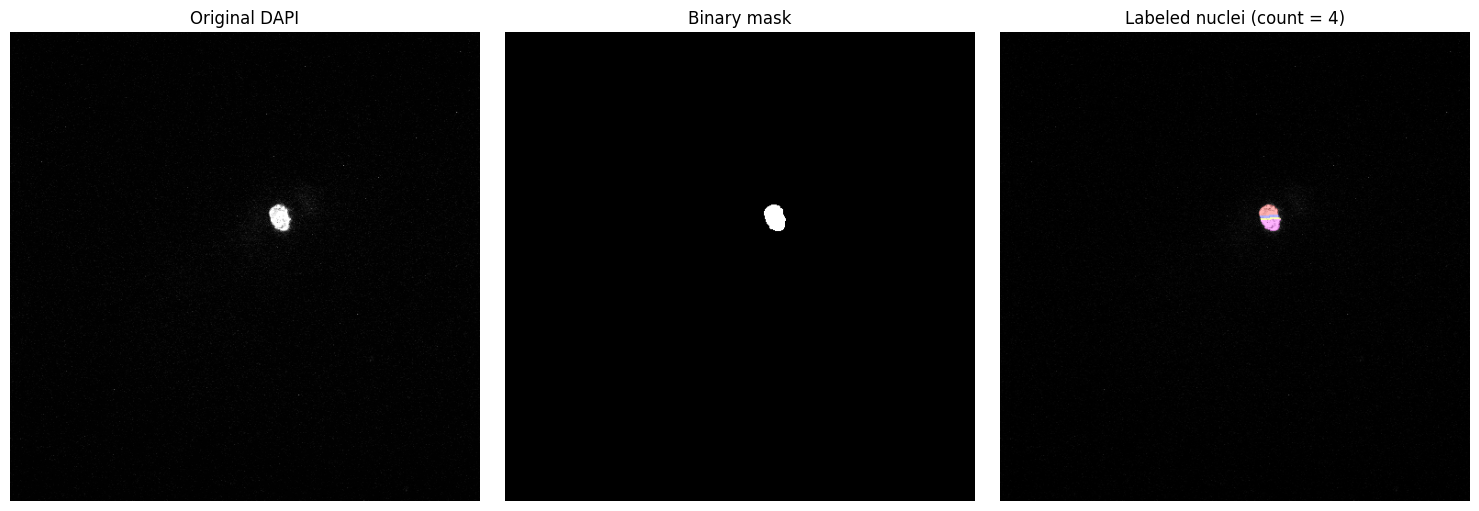

In [ ]:
# choose one z and one channel (adjust indices to your DAPI channel)
z_idx = 0          # first z-slice
c_idx = 0          # DAPI channel index
img = img_4d[z_idx, c_idx]        # 2D (512, 512)

# 2. Preprocessing: smooth to reduce noise
smoothed = filters.gaussian(img, sigma=1.0)

# 3. Thresholding: separate nuclei from background
thr = filters.threshold_otsu(smoothed)
binary = smoothed > thr

# 4. Morphological cleanup
binary = morphology.remove_small_objects(binary, min_size=100)
binary = morphology.remove_small_holes(binary, area_threshold=100)

# 5. Distance transform + watershed for instance separation
distance = ndi.distance_transform_edt(binary)
local_max = morphology.local_maxima(distance)
markers, _ = ndi.label(local_max)
labels = segmentation.watershed(-distance, markers, mask=binary)

# 6. Count nuclei
n_nuclei = labels.max()
print("Number of nuclei:", n_nuclei)

# 7. figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original DAPI")
axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

overlay = color.label2rgb(labels, image=img, bg_label=0, alpha=0.3)
axes[2].imshow(overlay)
axes[2].set_title(f"Labeled nuclei (count = {n_nuclei})")
axes[2].axis("off")

plt.tight_layout()
plt.show()




In [1]:


# 1. Load FOV 
path = r"D:/F1_CCTB/data/S-BSST700/selected-tiles/selected-tiles/out_opt_flow_registered_X10_Y2_c02_DAPI.tif"
img = io.imread(path)


# 2. Preprocessing: smooth to reduce noise
#This suppresses high‑frequency noise (random bright/dark speckles) while keeping the general shape of nuclei, so Otsu thresholding and the distance transform behave more stably.
#Smaller sigma (e.g. 0.5) → light smoothing, preserves fine details but less denoising.
# Larger sigma (e.g. 2–3) → stronger smoothing, removes more noise but also blurs small or closely spaced nuclei together.
#So sigma=1.2 is a moderate blur chosen to clean up the DAPI signal without merging nearby nuclei too much.

smoothed = filters.gaussian(img, sigma=1.2)

# 3. Thresholding: separate nuclei from background
thr = filters.threshold_otsu(smoothed)
binary = smoothed > thr

# 4. Morphological cleanup (debris removal + light opening to thin bridges)
binary = morphology.remove_small_objects(binary, min_size=100)
binary = morphology.remove_small_holes(binary, area_threshold=10)
binary = morphology.opening(binary, morphology.disk(1))

# 5. Distance transform + watershed for instance separation
distance = ndi.distance_transform_edt(binary)

# smooth distance map so each nucleus has ~1 maximum one broad peak instead of many noisy local maxima.
distance_smooth = filters.gaussian(distance, sigma=1.0)

# peaks as markers using peak_local_max
coords = feature.peak_local_max(
    distance_smooth,
    min_distance=1,      # tune based on smallest nucleus radius
    threshold_rel=0.02,   # ignore very weak peaks
    labels=binary
)

markers = np.zeros_like(img, dtype=int)
markers[tuple(coords.T)] = np.arange(1, coords.shape[0] + 1)

labels = segmentation.watershed(-distance_smooth, markers, mask=binary)

# 6. Filter by area: keep only objects within [min_area, max_area]
min_area = 60      # remove very small fragments
max_area = 1500    # remove big debris

props = measure.regionprops(labels)
mask_keep = np.zeros_like(labels, dtype=bool)

for p in props:
    if min_area <= p.area <= max_area:
        mask_keep[labels == p.label] = True

labels = measure.label(mask_keep)

n_nuclei = labels.max()
print("Number of nuclei:", n_nuclei)

# 7. figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original DAPI")
axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

overlay = color.label2rgb(labels, image=img, bg_label=0, alpha=0.3)
axes[2].imshow(overlay)
axes[2].set_title(f"Labeled nuclei (count = {n_nuclei})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


NameError: name 'io' is not defined

Processing FOV out_opt_flow_registered_X10_Y10_c01_DAPI (1/760)
Processing FOV out_opt_flow_registered_X10_Y10_c02_DAPI (2/760)
Processing FOV out_opt_flow_registered_X10_Y10_c03_DAPI (3/760)
Processing FOV out_opt_flow_registered_X10_Y10_c04_DAPI (4/760)
Processing FOV out_opt_flow_registered_X10_Y11_c01_DAPI (5/760)
Processing FOV out_opt_flow_registered_X10_Y11_c02_DAPI (6/760)
Processing FOV out_opt_flow_registered_X10_Y11_c03_DAPI (7/760)
Processing FOV out_opt_flow_registered_X10_Y11_c04_DAPI (8/760)
Processing FOV out_opt_flow_registered_X10_Y12_c01_DAPI (9/760)
Processing FOV out_opt_flow_registered_X10_Y12_c02_DAPI (10/760)
Processing FOV out_opt_flow_registered_X10_Y12_c03_DAPI (11/760)
Processing FOV out_opt_flow_registered_X10_Y12_c04_DAPI (12/760)


KeyboardInterrupt: 

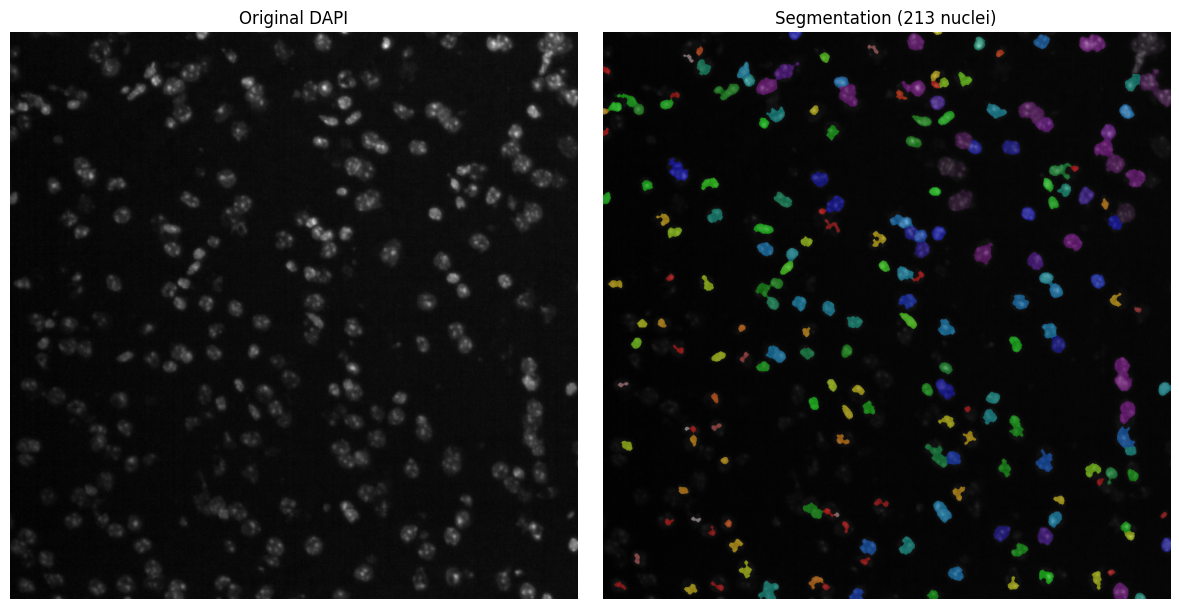

In [2]:
import glob
import os
import numpy as np
import pandas as pd
import skimage.io as io
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.morphology import opening, closing, remove_small_objects, disk
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# Paths (using raw strings)
dapi_pattern = r"D:\F1_CCTB\data\S-BSST700\selected-tiles\selected-tiles\out_opt_flow_registered_*_DAPI.tif"
diagnostic_dir = r"D:\F1_CCTB\output\diagnostic"
os.makedirs(diagnostic_dir, exist_ok=True)

csv_results = []

image_paths = glob.glob(dapi_pattern)
if len(image_paths) == 0:
    print("No DAPI images found matching the pattern.")
else:
    total = len(image_paths)
    # Inside the for loop
for idx, dapi_path in enumerate(image_paths):
    fov_name = os.path.basename(dapi_path).replace('.tif', '')
    print(f"Processing FOV {fov_name} ({idx+1}/{total})")

    img = io.imread(dapi_path)
    thresh = threshold_otsu(img)
    binary = img > thresh
    binary = opening(binary, disk(2))
    binary = closing(binary, disk(3))
    binary = remove_small_objects(binary, min_size=80)
    distance = ndi.distance_transform_edt(binary)
    coords = peak_local_max(distance, labels=binary, min_distance=10, exclude_border=False)
    markers = np.zeros_like(img, dtype=int)
    markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    labels_ws = watershed(-distance, markers, mask=binary)
    n_nuclei = np.max(labels_ws)

    csv_results.append({'fov': fov_name, 'nucleus_count': n_nuclei})

    # Plotting inside the loop
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Original DAPI")
    ax[0].axis('off')
    ax[1].imshow(img, cmap='gray')
    ax[1].imshow(labels_ws, cmap='nipy_spectral', alpha=0.5)
    ax[1].set_title(f"Segmentation ({n_nuclei} nuclei)")
    ax[1].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(diagnostic_dir, f"{fov_name}_diagnostic.png"))
    plt.close(fig)


(78, 512, 512) uint8
Otsu threshold: 69


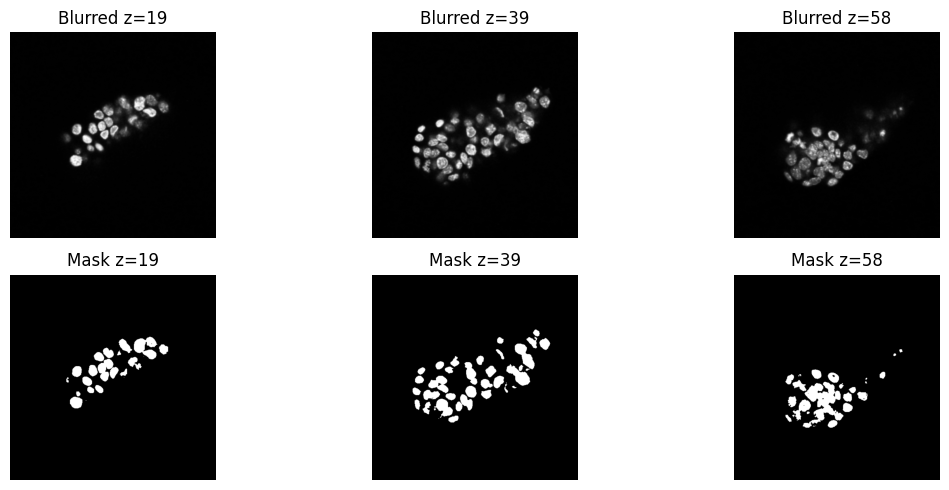

In [ ]:
#1. Load 3D DAPI stack
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Load 3D grayscale DAPI stack (Z, Y, X)
dapi = io.imread("dapi_stack.tif")
print(dapi.shape, dapi.dtype)

#2. 3D Gaussian blur (Fiji: Gaussian Blur 3D)
from scipy.ndimage import gaussian_filter

# Sigma in voxels; to data
sigma_z, sigma_y, sigma_x = 1.0, 1.0, 1.0
dapi_blur = gaussian_filter(dapi, sigma=(sigma_z, sigma_y, sigma_x))


#3. Global threshold to binary mask (Fiji: Image → Adjust → Threshold)

from skimage.filters import threshold_otsu

# Computing Otsu threshold on the whole stack
thr = threshold_otsu(dapi_blur)
nuclei_mask = dapi_blur > thr  # boolean 3D array
print("Otsu threshold:", thr)

# Quick check of some slices
z_slices_to_show = [dapi.shape[0]//4, dapi.shape[0]//2, 3*dapi.shape[0]//4]

fig, axes = plt.subplots(2, len(z_slices_to_show), figsize=(12, 5))
for i, z in enumerate(z_slices_to_show):
    axes[0, i].imshow(dapi_blur[z], cmap="gray")
    axes[0, i].set_title(f"Blurred z={z}")
    axes[0, i].axis("off")

    axes[1, i].imshow(nuclei_mask[z], cmap="gray")
    axes[1, i].set_title(f"Mask z={z}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()





In [3]:
#4A. Distance-transform-based watershed (MorphoLibJ analog)

from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

# 1) Distance transform of binary mask
distance = distance_transform_edt(nuclei_mask)  # 3D distance map [web:5][web:9]

# 2) Find local maxima as markers (tune min_distance)
coords = peak_local_max(
    distance,
    footprint=np.ones((3, 3, 3), dtype=bool),
    labels=nuclei_mask,
)
markers = np.zeros_like(distance, dtype=np.int32)
for i, (z, y, x) in enumerate(coords, start=1):
    markers[z, y, x] = i

# Optional: slightly dilate markers to make them more robust
from scipy.ndimage import binary_dilation

markers_dilated = np.zeros_like(markers)
for label_id in range(1, markers.max() + 1):
    m = markers == label_id
    m_dil = binary_dilation(m, iterations=1)  # tune if needed
    markers_dilated[m_dil] = label_id

# 3) Watershed on negative distance (so peaks become basins)
labels_ws = watershed(-distance, markers_dilated, mask=nuclei_mask)
print("Number of labeled nuclei (watershed):", labels_ws.max())

Number of labeled nuclei (watershed): 3075


In [4]:
#5. Measure nuclei properties (volume, intensity) – Fiji’s results table
from skimage.measure import regionprops_table

# Choose which label image: labels_ws (watershed) or labels_filtered (CC)
labels = labels_ws  # or labels_filtered

props = regionprops_table(
    labels,
    intensity_image=dapi_blur,  # or original dapi
    properties=("label", "area", "bbox", "centroid", "max_intensity", "mean_intensity"),
)

import pandas as pd
df = pd.DataFrame(props)
print(df.head())
df.to_csv("nuclei_measurements.csv", index=False)


   label    area  bbox-0  bbox-1  bbox-2  bbox-3  bbox-4  bbox-5  centroid-0  \
0      1  7150.0      33     241     356      62     260     394   46.665734   
1      2  1703.0       0     185     283      13     202     306    5.096888   
2      3   528.0       0     198     294      13     205     307    6.359848   
3      4  4138.0       0     186     281      13     221     308    4.148623   
4      5  4108.0      34     256     356      60     277     394   45.216407   

   centroid-1  centroid-2  max_intensity  mean_intensity  
0  250.847832  373.691608          251.0      148.562797  
1  193.558426  296.091603          253.0      181.124486  
2  200.689394  299.842803          253.0      192.022727  
3  206.652489  293.750846          253.0      189.199130  
4  263.552580  368.283593          242.0      132.070351  


In [5]:
len(df)          # total number of rows / nuclei
df.head()        # first 5 rows (what you pasted)
df.tail()        # last 5 rows
df["label"].nunique()


3046